In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [3]:
df=pd.read_csv('Car_Price_Prediction.csv')
df.shape
df.info()
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 8 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Make          1000 non-null   object 
 1   Model         1000 non-null   object 
 2   Year          1000 non-null   int64  
 3   Engine Size   1000 non-null   float64
 4   Mileage       1000 non-null   int64  
 5   Fuel Type     1000 non-null   object 
 6   Transmission  1000 non-null   object 
 7   Price         1000 non-null   float64
dtypes: float64(2), int64(2), object(4)
memory usage: 62.6+ KB


,Year,Engine Size,Mileage,Price
count,1000.000000,1000.000000,1000.00000,1000.000000
mean,2010.688000,2.798300,97192.48700,25136.615530
std,6.288577,1.024137,59447.31576,5181.401368
min,2000.000000,1.000000,56.00000,6704.953524
25%,2005.000000,1.900000,44768.75000,21587.878370
50%,2011.000000,2.800000,94411.50000,25189.325247
75%,2016.000000,3.700000,148977.75000,28806.368974
max,2021.000000,4.500000,199867.00000,41780.504635


In [4]:
df.isnull().sum()

Make            0
Model           0
Year            0
Engine Size     0
Mileage         0
Fuel Type       0
Transmission    0
Price           0
dtype: int64

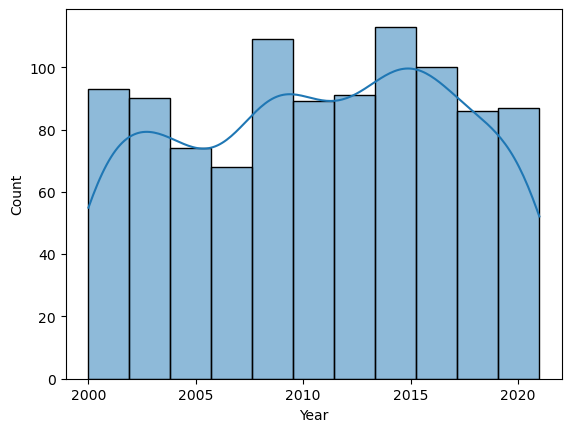

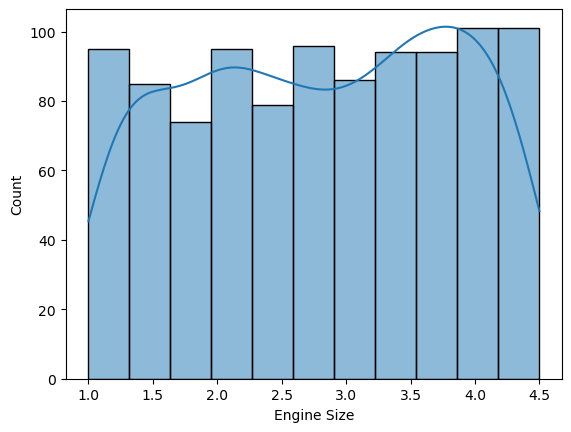

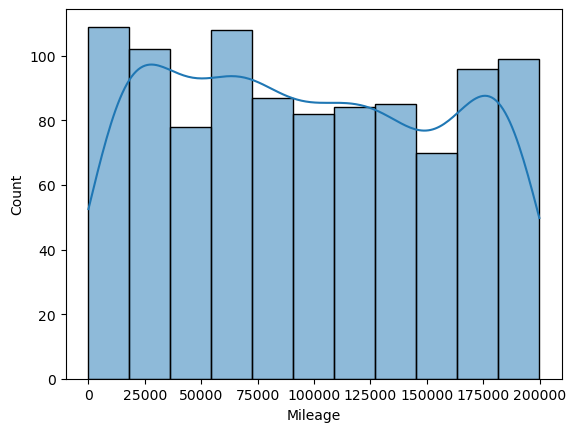

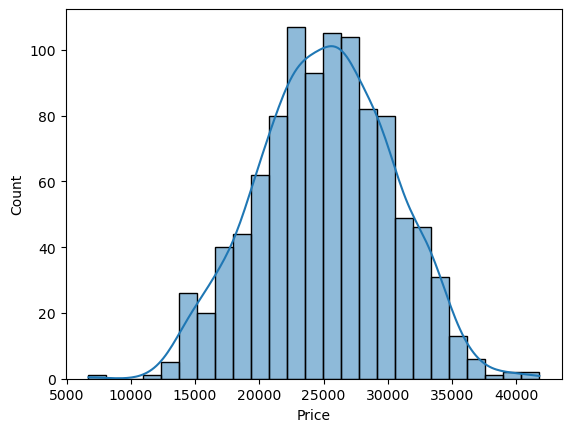

In [6]:
cols=['Year','Engine Size','Mileage','Price']
for col in cols:
    plt.figure()
    sns.histplot(x=df[col],kde=True)

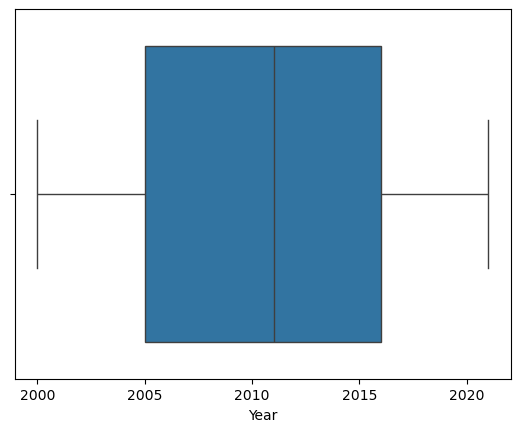

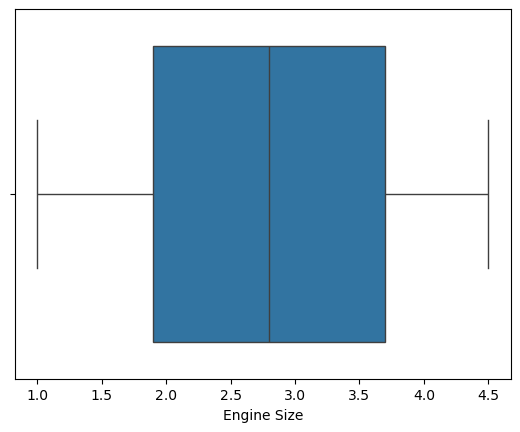

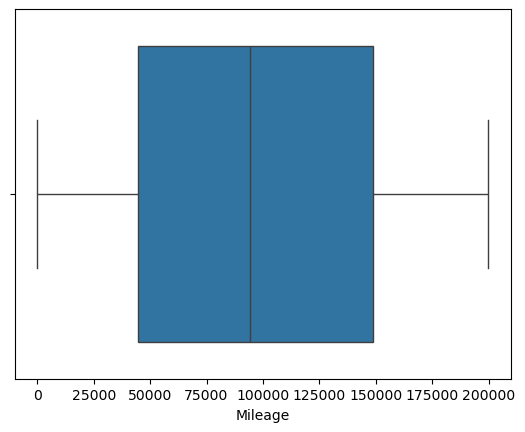

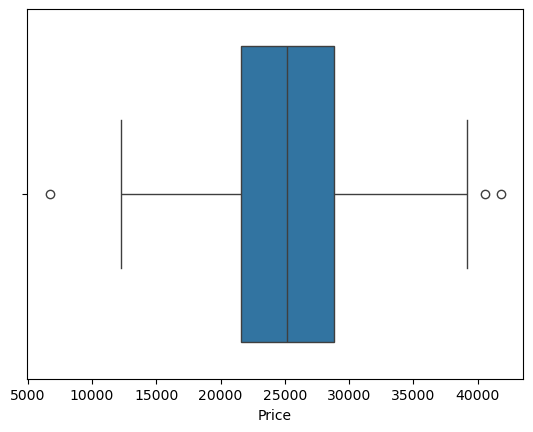

In [7]:
for col in cols:
    plt.figure()
    sns.boxplot(x=df[col])

<Axes: >

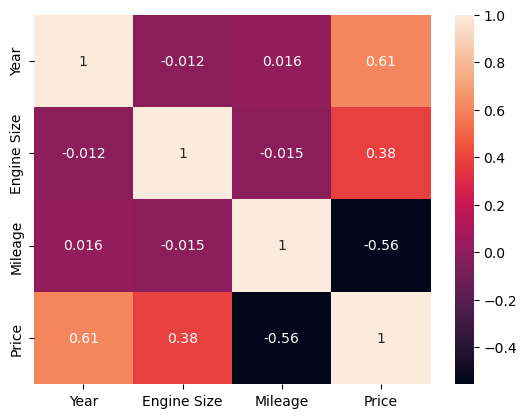

In [10]:
plt.figure()
sns.heatmap(df.corr(numeric_only=True),annot=True)

In [12]:
df.drop_duplicates(inplace=True)
df.shape

(1000, 8)

In [13]:
df.head()

,Make,Model,Year,Engine Size,Mileage,Fuel Type,Transmission,Price
0,Honda,Model B,2015,3.9,74176,Petrol,Manual,30246.207931
1,Ford,Model C,2014,1.7,94799,Electric,Automatic,22785.747684
2,BMW,Model B,2006,4.1,98385,Electric,Manual,25760.290347
3,Honda,Model B,2015,2.6,88919,Electric,Automatic,25638.003491
4,Honda,Model C,2004,3.4,138482,Petrol,Automatic,21021.386657


In [14]:
df_cleaned=df.copy()
df_cleaned.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 8 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Make          1000 non-null   object 
 1   Model         1000 non-null   object 
 2   Year          1000 non-null   int64  
 3   Engine Size   1000 non-null   float64
 4   Mileage       1000 non-null   int64  
 5   Fuel Type     1000 non-null   object 
 6   Transmission  1000 non-null   object 
 7   Price         1000 non-null   float64
dtypes: float64(2), int64(2), object(4)
memory usage: 62.6+ KB


In [15]:
df_cleaned.dtypes

Make             object
Model            object
Year              int64
Engine Size     float64
Mileage           int64
Fuel Type        object
Transmission     object
Price           float64
dtype: object

In [23]:
df_cleaned['Make'].value_counts()


Make
Ford      225
Audi      212
Honda     198
Toyota    187
BMW       178
Name: count, dtype: int64

In [20]:

df_cleaned['Model'].value_counts()


Model
Model B    212
Model C    205
Model A    202
Model D    197
Model E    184
Name: count, dtype: int64

In [21]:

df_cleaned['Fuel Type'].value_counts()


Fuel Type
Diesel      344
Petrol      331
Electric    325
Name: count, dtype: int64

In [22]:

df_cleaned['Transmission'].value_counts()

Transmission
Manual       511
Automatic    489
Name: count, dtype: int64

In [24]:
categorical_cols = ['Make', 'Model', 'Fuel Type', 'Transmission']

df_encoded = pd.get_dummies(
    df_cleaned,
    columns=categorical_cols,
    drop_first=True,  # optional
    dtype=int
)

print(df_encoded.head())
print(df_encoded.shape)

   Year  Engine Size  Mileage         Price  Make_BMW  Make_Ford  Make_Honda  \
0  2015          3.9    74176  30246.207931         0          0           1   
1  2014          1.7    94799  22785.747684         0          1           0   
2  2006          4.1    98385  25760.290347         1          0           0   
3  2015          2.6    88919  25638.003491         0          0           1   
4  2004          3.4   138482  21021.386657         0          0           1   

   Make_Toyota  Model_Model B  Model_Model C  Model_Model D  Model_Model E  \
0            0              1              0              0              0   
1            0              0              1              0              0   
2            0              1              0              0              0   
3            0              1              0              0              0   
4            0              0              1              0              0   

   Fuel Type_Electric  Fuel Type_Petrol  Transmiss

In [26]:
df_encoded.columns

Index(['Year', 'Engine Size', 'Mileage', 'Price', 'Make_BMW', 'Make_Ford',
       'Make_Honda', 'Make_Toyota', 'Model_Model B', 'Model_Model C',
       'Model_Model D', 'Model_Model E', 'Fuel Type_Electric',
       'Fuel Type_Petrol', 'Transmission_Manual'],
      dtype='object')

In [27]:
from sklearn.preprocessing import StandardScaler
cols=['Year', 'Engine Size', 'Mileage']
scaler=StandardScaler()
df_encoded[cols]=scaler.fit_transform(df_encoded[cols])
df_encoded

,Year,Engine Size,Mileage,Price,Make_BMW,Make_Ford,Make_Honda,Make_Toyota,Model_Model B,Model_Model C,Model_Model D,Model_Model E,Fuel Type_Electric,Fuel Type_Petrol,Transmission_Manual
0,0.686031,1.076274,-0.387368,30246.207931,0,0,1,0,1,0,0,0,0,1,1
1,0.526933,-1.072952,-0.040282,22785.747684,0,1,0,0,0,1,0,0,1,0,0
2,-0.745852,1.271658,0.020070,25760.290347,1,0,0,0,1,0,0,0,1,0,1
3,0.686031,-0.193723,-0.139243,25638.003491,0,0,1,0,1,0,0,0,1,0,0
4,-1.064048,0.587813,0.694904,21021.386657,0,0,1,0,0,1,0,0,0,1,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
995,-1.382244,-0.877568,-1.544113,22765.597091,0,0,0,1,0,0,1,0,0,1,1
996,1.481521,0.294737,0.873807,30392.575567,0,0,1,0,1,0,0,0,0,0,1
997,-0.427656,-0.877568,1.652617,16446.892292,0,1,0,0,0,1,0,0,0,1,0
998,-1.223146,1.564734,-1.631613,27396.156708,0,0,0,1,0,0,0,0,0,1,0


In [31]:
from sklearn.model_selection import train_test_split
x=df_encoded.drop(columns=['Price'])
y=df_encoded['Price']
x


,Year,Engine Size,Mileage,Make_BMW,Make_Ford,Make_Honda,Make_Toyota,Model_Model B,Model_Model C,Model_Model D,Model_Model E,Fuel Type_Electric,Fuel Type_Petrol,Transmission_Manual
0,0.686031,1.076274,-0.387368,0,0,1,0,1,0,0,0,0,1,1
1,0.526933,-1.072952,-0.040282,0,1,0,0,0,1,0,0,1,0,0
2,-0.745852,1.271658,0.020070,1,0,0,0,1,0,0,0,1,0,1
3,0.686031,-0.193723,-0.139243,0,0,1,0,1,0,0,0,1,0,0
4,-1.064048,0.587813,0.694904,0,0,1,0,0,1,0,0,0,1,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
995,-1.382244,-0.877568,-1.544113,0,0,0,1,0,0,1,0,0,1,1
996,1.481521,0.294737,0.873807,0,0,1,0,1,0,0,0,0,0,1
997,-0.427656,-0.877568,1.652617,0,1,0,0,0,1,0,0,0,1,0
998,-1.223146,1.564734,-1.631613,0,0,0,1,0,0,0,0,0,1,0


In [32]:
y

0      30246.207931
1      22785.747684
2      25760.290347
3      25638.003491
4      21021.386657
           ...     
995    22765.597091
996    30392.575567
997    16446.892292
998    27396.156708
999    31620.864907
Name: Price, Length: 1000, dtype: float64

In [41]:
x_train, x_test, y_train, y_test = train_test_split( x, y, test_size=0.20, random_state=42)
x_train

,Year,Engine Size,Mileage,Make_BMW,Make_Ford,Make_Honda,Make_Toyota,Model_Model B,Model_Model C,Model_Model D,Model_Model E,Fuel Type_Electric,Fuel Type_Petrol,Transmission_Manual
29,-1.541342,0.099353,-1.358091,0,0,1,0,1,0,0,0,1,0,0
535,-0.586754,-0.682184,1.569982,0,0,0,0,0,0,0,1,1,0,0
695,0.208737,0.099353,1.260847,0,0,0,0,0,1,0,0,1,0,0
557,-1.064048,-1.561412,-0.809129,1,0,0,0,0,0,1,0,0,0,0
836,1.481521,0.978582,0.961424,0,1,0,0,0,0,0,1,1,0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
106,-1.064048,-0.877568,-0.186115,0,0,0,0,0,0,0,1,0,1,1
270,-1.223146,0.392429,-0.723313,0,0,1,0,0,0,0,0,0,1,1
860,1.163325,0.978582,-1.552276,0,0,0,0,0,0,1,0,0,1,0
435,-0.586754,0.197045,0.449758,0,0,0,0,0,0,0,0,0,1,1


In [42]:
from sklearn.linear_model import LinearRegression
model = LinearRegression()
model.fit(x_train,y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [43]:
y_pred=model.predict(x_test)
y_pred

array([25695.70851693, 29413.2917892 , 26781.43215542, 27492.50089817,
       27578.32713543, 19648.82806891, 23373.70778804, 27229.57138933,
       30460.33116021, 23952.07028603, 28300.15914534, 22333.51539847,
       18588.57276324, 26200.47796075, 24464.69049434, 28189.12884294,
       21176.34359358, 27691.39929461, 24346.52294997, 30787.77560306,
       21750.08194276, 21962.42655406, 16974.4697385 , 22952.20077102,
       16365.31112125, 26229.23618555, 28649.68688154, 21095.67768058,
       22665.39719354, 29625.55539068, 19768.17743982, 24123.87848305,
       22372.35947552, 34552.56260802, 29494.84877123, 29445.81192601,
       18433.08011651, 28885.87649596, 30911.9712508 , 23846.58552812,
       30851.95813301, 26336.43132639, 29084.08043257, 25479.52305122,
       21065.89222941, 21142.89713086, 32379.87723833, 32631.86094089,
       24850.09824569, 22145.61821559, 31976.73835749, 21063.34979529,
       24083.20183121, 19067.24502209, 21768.06559087, 27043.06811673,
      

In [48]:
from sklearn.metrics import r2_score
r2=r2_score(y_test,y_pred)

n=x_test.shape[0]
p=x_test.shape[1]
adjr2= 1-((1-r2)*(n-1)/(n-p-1))
r2

0.8170961815663226

In [49]:
adjr2

0.803254811522693

In [51]:
from sklearn.metrics import mean_absolute_error
from sklearn.metrics import mean_squared_error
import numpy as np

mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))

print("MAE:", mae)
print("RMSE:", rmse)

MAE: 1810.554757577633
RMSE: 2237.2910425919263


In [53]:
print("Train R²:", model.score(X_train, y_train))
print("Test R² :", model.score(X_test, y_test))

Train R²: 0.8457634186792121
Test R² : 0.8170961815663226


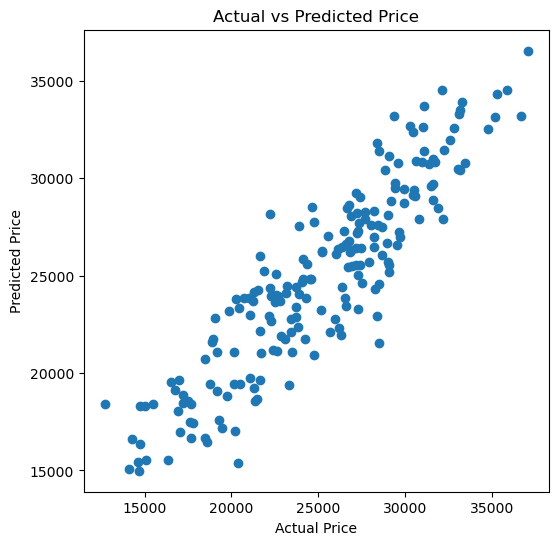

In [54]:
import matplotlib.pyplot as plt

plt.figure(figsize=(6,6))
plt.scatter(y_test, y_pred)
plt.xlabel("Actual Price")
plt.ylabel("Predicted Price")
plt.title("Actual vs Predicted Price")
plt.show()